# EDA датасета MicroLens-100K

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import data_profiling
from pathlib import Path
from data_profiling import ProfileReport

In [2]:
data_path = Path("../../data/raw/microlens")
interactions_path = data_path / "MicroLens-100k_pairs.csv"
titles_path = data_path / "MicroLens-100k_title_en.csv"

In [3]:
with open(interactions_path, "r") as file:
    print(file.readline())
    print(file.readline())
    print(file.readline())

user,item,timestamp

36121,9580,1583378629552

26572,9580,1583436719018



In [4]:
with open(titles_path, "r") as file:
    print(file.readline())
    print(file.readline())
    print(file.readline())

1, Gu long song gaga bad

2, beautiful dish with 5 pounds of duck intestines

3, This sudden reversal



## EDA for interaction data

In [5]:
interaction_df = pd.read_csv(interactions_path)
interaction_df.head(10)

,user,item,timestamp
0,36121,9580,1583378629552
1,26572,9580,1583436719018
2,94805,9580,1584083806481
3,37550,9580,1584412681021
4,89825,9580,1584649439020
5,14601,9580,1584848802432
6,15061,9580,1585388171106
7,6364,9580,1585390736041
8,99661,9580,1585392581153
9,57849,9580,1585394954324


In [6]:
print("Размер таблицы взаимодействий:", interaction_df.shape)

Размер таблицы взаимодействий: (719405, 3)


In [7]:
profile_interaction = ProfileReport(interaction_df, title = "Interaction profile report")
profile_interaction

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:00<00:00,  3.60it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
interaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 719405 entries, 0 to 719404
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user       719405 non-null  int64
 1   item       719405 non-null  int64
 2   timestamp  719405 non-null  int64
dtypes: int64(3)
memory usage: 16.5 MB


In [9]:
interaction_df.isna().sum()

user         0
item         0
timestamp    0
dtype: int64

In [10]:
interaction_df.duplicated().sum()

np.int64(0)

In [11]:
n_users = interaction_df["user"].nunique()
n_items = interaction_df["item"].nunique()
n_interactions = len(interaction_df)

print("Количество пользователей:", n_users)
print("Количество объектов:", n_items)
print("Количество взаимодействий:", n_interactions)

Количество пользователей: 100000
Количество объектов: 19738
Количество взаимодействий: 719405


## EDA for titles data

In [12]:
titles_df = pd.read_csv(titles_path, header=None, names = ["item", "title"])
titles_df.head(10)

,item,title
0,1,Gu long song gaga bad
1,2,beautiful dish with 5 pounds of duck intestines
2,3,This sudden reversal
3,4,pumpkin play armor new outfit
4,5,the wife a day brush 200
5,6,What if the accompaniment suddenly stops? See...
6,7,become the North state family alliance leader...
7,8,a friend sent a box of sea urchins
8,9,salted fish brother: the method of fighting p...
9,10,Fatherland man may not be a nice guy


In [13]:
print("Размер таблицы названий:", titles_df.shape)

Размер таблицы названий: (19738, 2)


In [14]:
profile_titles = ProfileReport(titles_df, title = "Titles profile report")
profile_interaction

In [15]:
titles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19738 entries, 0 to 19737
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   item    19738 non-null  int64 
 1   title   19738 non-null  object
dtypes: int64(1), object(1)
memory usage: 308.5+ KB


In [16]:
titles_df.isna().sum()

item     0
title    0
dtype: int64

In [17]:
titles_df.duplicated().sum()

np.int64(0)

## Активность пользователей и популярность объектов

In [19]:
user_interactions = interaction_df.groupby("user").size()
user_interactions.head()

user
1    5
2    7
3    5
4    5
5    5
dtype: int64

In [20]:
user_interactions.describe()

count    100000.000000
mean          7.194050
std           4.563348
min           5.000000
25%           5.000000
50%           6.000000
75%           8.000000
max         218.000000
dtype: float64

In [21]:
item_interactions = interaction_df.groupby("item").size()

In [22]:
item_interactions.describe()

count    19738.000000
mean        36.447715
std         43.571139
min          1.000000
25%          9.000000
50%         22.000000
75%         49.000000
max        640.000000
dtype: float64

In [26]:
%matplotlib inline

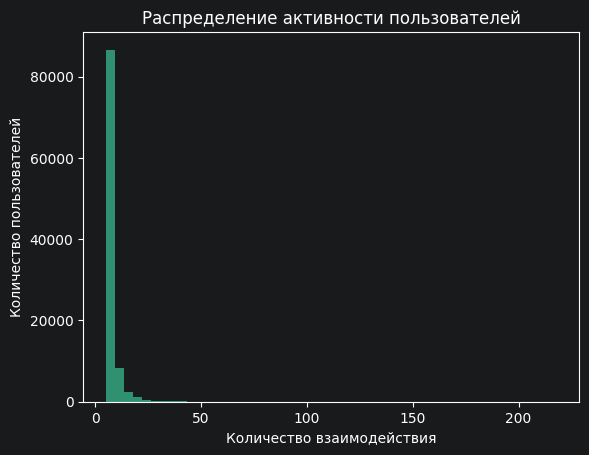

In [27]:
plt.hist(user_interactions, bins = 50)
plt.xlabel("Количество взаимодействия")
plt.ylabel("Количество пользователей")
plt.title("Распределение активности пользователей")
plt.show()

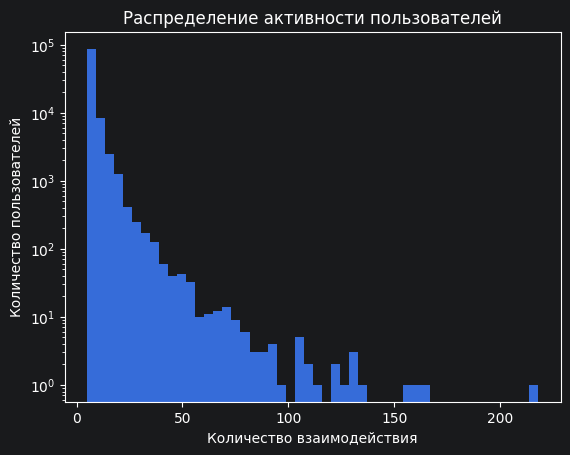

In [33]:
plt.hist(user_interactions, bins = 50)
plt.yscale("log")
plt.xlabel("Количество взаимодействия")
plt.ylabel("Количество пользователей")
plt.title("Распределение активности пользователей")
plt.show()

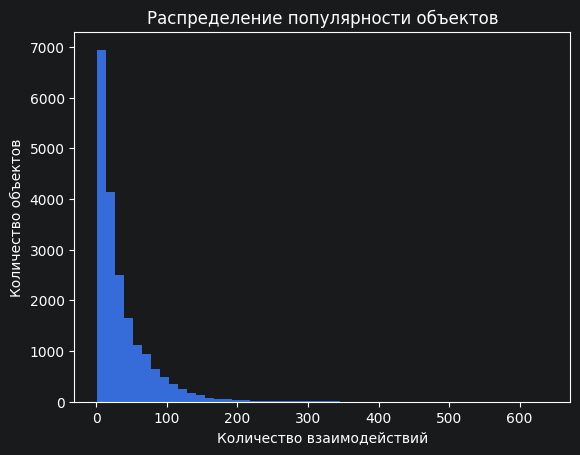

In [31]:
plt.hist(item_interactions, bins = 50)
plt.xlabel("Количество взаимодействий")
plt.ylabel("Количество объектов")
plt.title("Распределение популярности объектов")
plt.show()

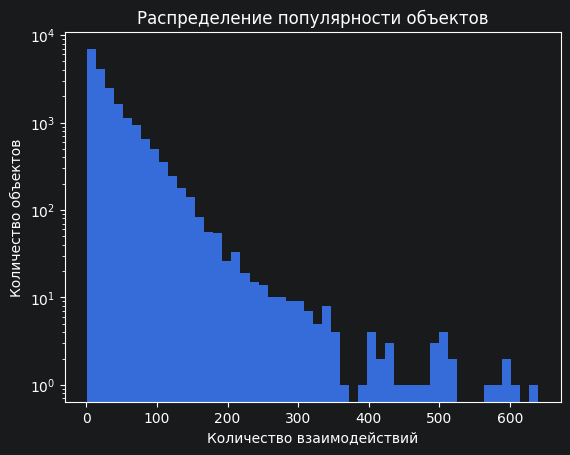

In [32]:
plt.hist(item_interactions, bins = 50)
plt.yscale("log")
plt.xlabel("Количество взаимодействий")
plt.ylabel("Количество объектов")
plt.title("Распределение популярности объектов")
plt.show()

In [30]:
item_interactions.sort_values(ascending = False).head(10)

item
16981    640
3260     604
15775    599
6539     590
16537    584
9512     564
7586     524
18361    519
680      505
15312    503
dtype: int64

Распределение популярности объектов скошено вправо: большинство объектов имеет небольшое число взаимодействий. Небольшая доля
объектов получает существенно больше взаимодействий.

In [34]:
user_item_counts = interaction_df.groupby(["user", "item"]).size()
user_item_counts.head(10)

user  item 
1     1707     1
      1958     1
      6346     1
      15223    1
      17700    1
2     915      1
      3775     1
      5299     1
      9127     1
      9500     1
dtype: int64

In [35]:
user_item_counts.max()

np.int64(1)

In [36]:
len(user_item_counts)

719405

In [37]:
len(interaction_df)

719405

### Вывод

Повторных взаимодействий одной и той же пары пользователь–объект в датасете
не обнаружено.
Количество уникальных пар `user-item` совпадает с общим количеством
взаимодействий и составляет 719 405.

Таким образом, каждое наблюдение соответствует уникальной паре
пользователь–объект.